In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from matplotlib.colors import XKCD_COLORS
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.linalg import orthogonal_procrustes
import plotly.express as px

Now that we have a dataset, the first thing we need to do is load it and visualize it.

In [2]:
directory = "./datasets/"
data_prefix = "dataset_task-memoryscenes_roi-fef_r"
control_prefix = "dataset_task-memoryscenes_roi-rnd_r"

Unfortunately, it isn't possible to visualize all the voxels. However, what we can do is reduce the dimensions as much as possible. Let's aim to capture at least 97% of the data. One option is of course, t-SNE, but let's try PCA first to get rid of the noise.

In [3]:
def pca_by_threshold(data, threshold=0.97):
    pca = PCA()
    pca_x = pca.fit_transform(data)
    exp_var = pca.explained_variance_ratio_
    cum_exp_var = np.cumsum(exp_var)
    threshold_match = np.where(cum_exp_var>=threshold)[0][0]
    reduced_x = pca_x[:,0:threshold_match+1]
    return reduced_x, pca

In [4]:
def pca_scree_plot(model):
    
    exp_var = model.explained_variance_ratio_
    cum_exp_var = np.cumsum(exp_var)

    fig, ax = plt.subplots(2,1, figsize=(16,8))
    sns.lineplot(x=np.arange(exp_var.shape[0]), y=exp_var, color=XKCD_COLORS["xkcd:rose pink"], ax=ax[0])
    sns.lineplot(x=np.arange(exp_var.shape[0]), y=cum_exp_var, color=XKCD_COLORS["xkcd:seafoam"], ax=ax[1])
    ax[1].set_xlabel("Principal Component Number")
    ax[0].set_ylabel("Variance Explained")
    ax[1].set_ylabel("Cumulative Variance Explained")

    return fig, ax

In [5]:
def create_3d_dataset(data, orig_df):
    tsne = TSNE(n_components=3, 
            perplexity=30, 
            random_state=42
           )
    tsne_3d = tsne.fit_transform(data)
    tsne_df = pd.DataFrame(tsne_3d, columns=['x', 'y', 'z'])
    tsne_df['Time'] = orig_df['scan_time']
    tsne_df['Runs'] = orig_df['run']
    tsne_df['Subjects'] = orig_df['subj']
    tsne_df['Session'] = orig_df['sess']
    return tsne_df

In [6]:
def visualize_3d_data(df_3d, roi_label, color_by=None):
    fig = px.scatter_3d(df_3d, x='x', y='y', z='z', color=color_by, opacity=0.7, 
                        size_max=3, title=f"3D t-SNE of {roi_label} by {color_by}")
    fig.show(renderer="iframe")

------------

In [34]:
roi_df = pd.read_csv(directory+data_prefix+"/"+data_prefix+"_date-2026-01-02_desc-vox_w_stim_hrf.csv", header=0)
con_df = pd.read_csv(directory+control_prefix+"/"+control_prefix+"_[-4 -8 21]_date-2026-01-02_desc-vox_w_stim_hrf.csv", header=0)

vcols = [col for col in roi_df.columns if col[0]=='v']
cvcols = [col for col in con_df.columns if col[0]=='v']

In [41]:
chosen_voxels = np.random.randint(1,len(cvcols), size=len(vcols))
chosen_voxels = ["v"+str(n) for n in chosen_voxels]

In [42]:
x = roi_df.loc[:, vcols].copy()
y = roi_df[['indoor', 'outdoor']].copy()

cx = con_df.loc[:, chosen_voxels].copy()
cy = con_df[['indoor', 'outdoor']].copy()

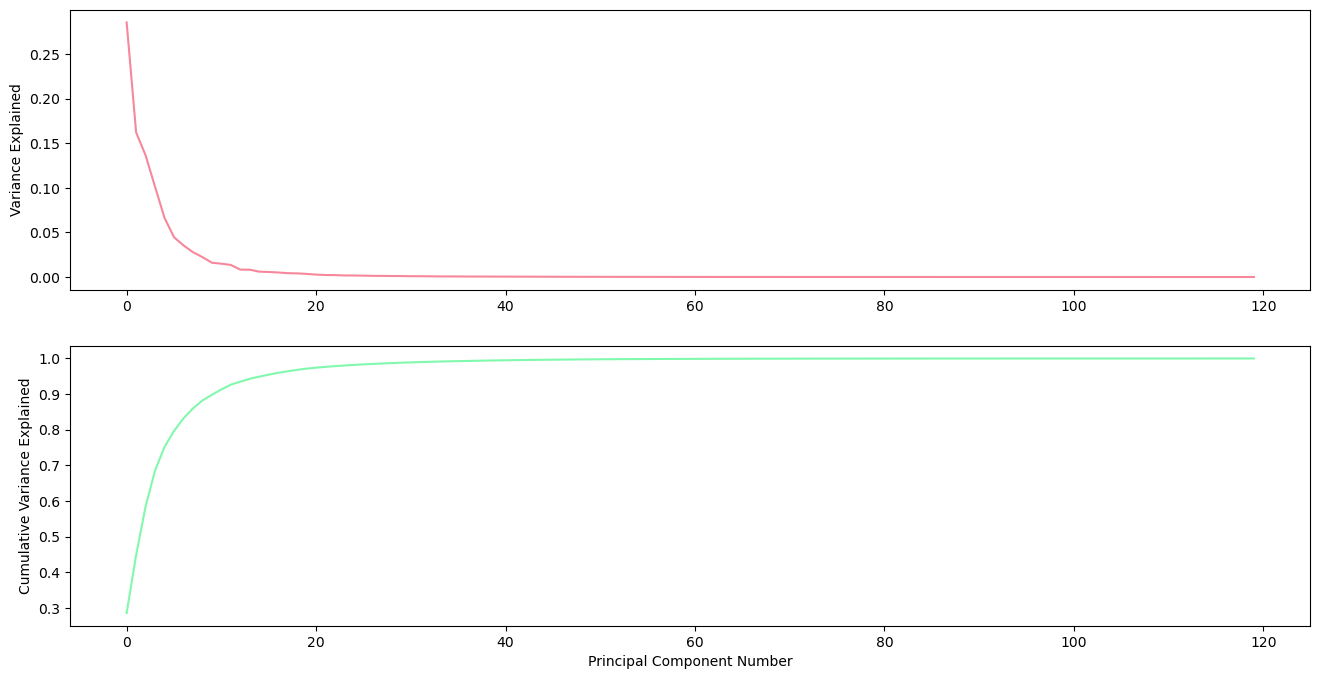

In [43]:
rfef_x_pca, rfef_model = pca_by_threshold(x)
fig, ax = pca_scree_plot(rfef_model)

And now for the control.

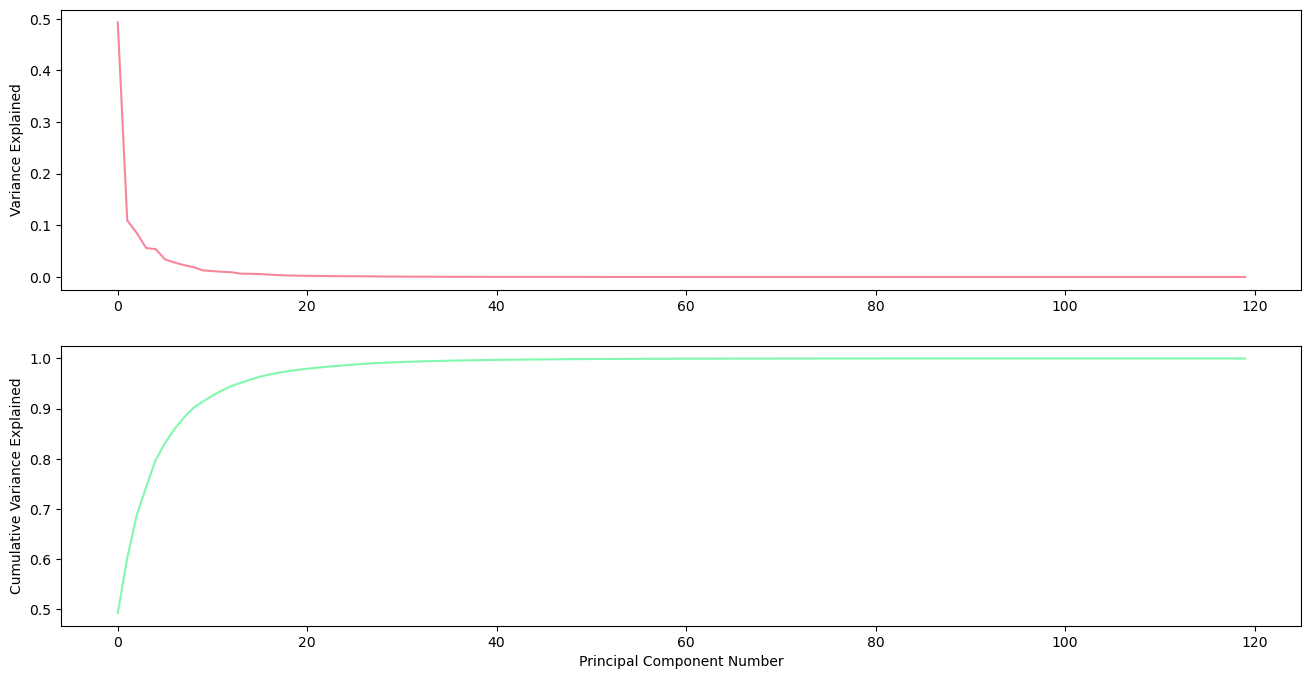

In [44]:
rrnd_x_pca, rrnd_model = pca_by_threshold(cx)
fig, ax = pca_scree_plot(rrnd_model)

We can see that we can capture most of the data with relatively few components. We will now take those principle components and further reduce them into three dimensions so that we can visualize the data.

In [45]:
rfef_x_pca_df = create_3d_dataset(rfef_x_pca, roi_df)

In [46]:
rrnd_x_pca_df = create_3d_dataset(rrnd_x_pca, con_df)

In [47]:
visualize_3d_data(rfef_x_pca_df, 'rFEF', color_by='Subjects')

In [48]:
visualize_3d_data(rrnd_x_pca_df, 'rcontrol', color_by='Subjects')

It looks like there _might_ be some kind of order here but right now, it's all a mess of strings. What we do know is that the answer _isn't_ scaling the data because they were scaled during timeseries extraction. 

-------

In [15]:
def hyperaligner(fixed_target, rotate_df, feature_list):
    transforming_matrix = rotate_df.loc[:,feature_list].to_numpy()
    transformation_matrix, _ = orthogonal_procrustes(transforming_matrix, fixed_target)
    transformed_matrix = transforming_matrix @ transformation_matrix
    ccf = np.corrcoef(transformed_matrix.flatten(),fixed_target.flatten())[0,1]
    return transformation_matrix, ccf

In [16]:
def pass_idx(new_df, old_df):
    new_df['Subject'] = old_df['subj']
    new_df['Session'] = old_df['sess']
    new_df['Run'] = old_df['run']
    new_df['Time'] = old_df['scan_time']
    new_df['Indoor'] = old_df['indoor']
    new_df['Outdoor'] = old_df['outdoor']
    return new_df

In [17]:
def best_transformation_target_finder(df, feature_list):
    master_tmat_list = []
    master_corr_list = []
    corr_sum_list = []
    
    for sub in df['subj'].unique():
        sub_idx = df[df['subj']==sub].copy()
        tmp_tmat = []
        tmp_corr = []
        
        for s in sub_idx['sess'].unique():
            tmat_list = []
            corr_list = []
            target = sub_idx[sub_idx['sess']==s].loc[:,feature_list].to_numpy()
            maxcoeff = []
            
            for t in sub_idx['sess'].unique():
    
                if t==s:
                    continue
    
                sub_ses_df = sub_idx[sub_idx['sess']==t]
                transformation_matrix, ccf = hyperaligner(target, sub_ses_df, feature_list)
                
                tmat_list.append((t, transformation_matrix))
                corr_list.append((t, ccf))
                maxcoeff.append(ccf)
            tmp_tmat.append((s, tmat_list))
            tmp_corr.append((s, max(maxcoeff)))
        master_tmat_list.append((sub, tmp_tmat))
        master_corr_list.append((sub, tmp_corr))
    return master_tmat_list, master_corr_list

In [18]:
def best_transformation(correlation_list):
    max_idx = {}
    for sub in correlation_list:
        id_finder = []
        for sess in sub[1]:
            id_finder.append(sess[1])
        idx = np.where(id_finder==np.max(id_finder))
        max_idx[sub[0]] = idx
    return max_idx

In [19]:
def transformer(df, feature_list, transformation_mat_list, correlation_list):
    corr_idx = best_transformation(correlation_list)
    x_proc = df[feature_list].copy()
    for i, sub in enumerate(df['subj'].unique()):
        sub_idx = df[df['subj']==sub].copy()
        mid = corr_idx[sub][0][0]
        
        for j, s in enumerate(transformation_mat_list[i][1][mid][1]):
    
            transformation_matrix = s[1] # the template transformations
            transforming_matrix = sub_idx[sub_idx['sess']==s[0]].loc[:,feature_list].to_numpy()
            transformed_matrix = transforming_matrix @ transformation_matrix
            x_proc.loc[sub_idx[sub_idx['sess']==s[0]].index,feature_list] = transformed_matrix
    x_proc = pass_idx(x_proc, df)
    return x_proc

In [20]:
rfef_trans_list, rfef_corr_list = best_transformation_target_finder(roi_df, vcols)
rfef_x_proc = transformer(roi_df, vcols, rfef_trans_list, rfef_corr_list)

In [49]:
rrnd_trans_list, rrnd_corr_list = best_transformation_target_finder(con_df, chosen_voxels)
rrnd_x_proc = transformer(con_df, chosen_voxels, rrnd_trans_list, rrnd_corr_list)

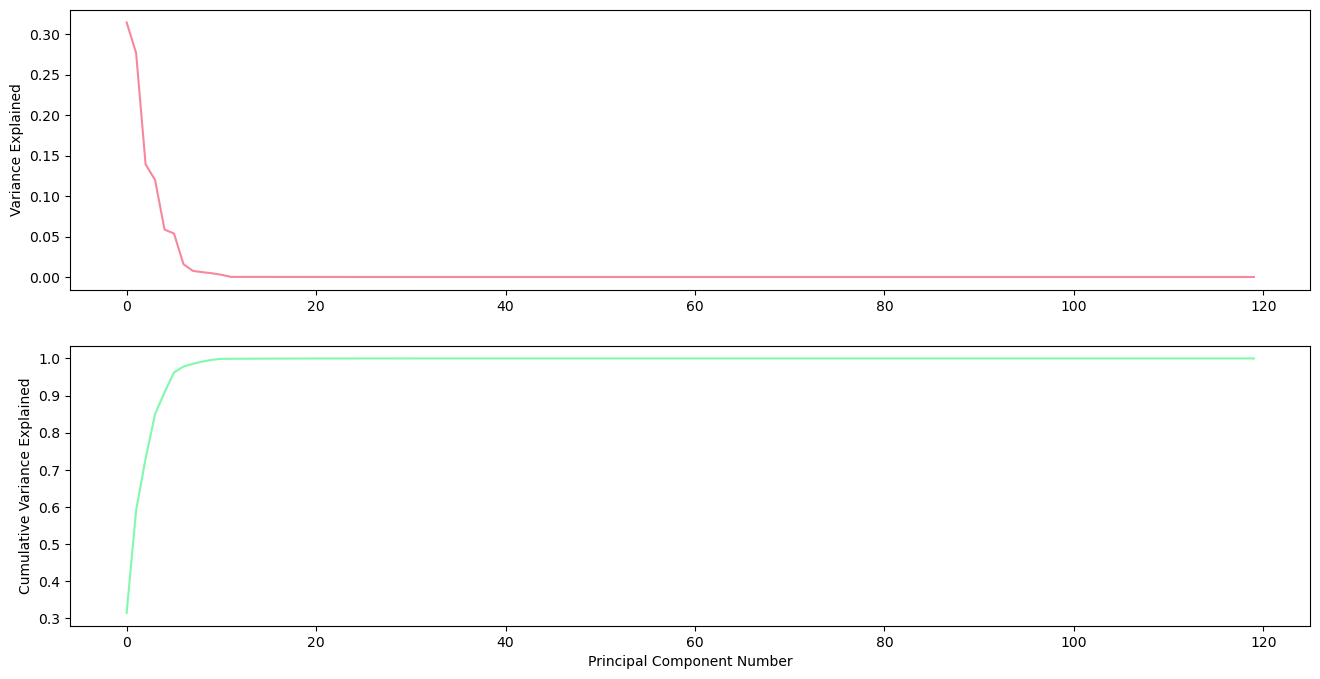

In [22]:
rfef_x_proc_pca, rfef_pca_model = pca_by_threshold(rfef_x_proc[vcols])
fig, ax = pca_scree_plot(rfef_pca_model)

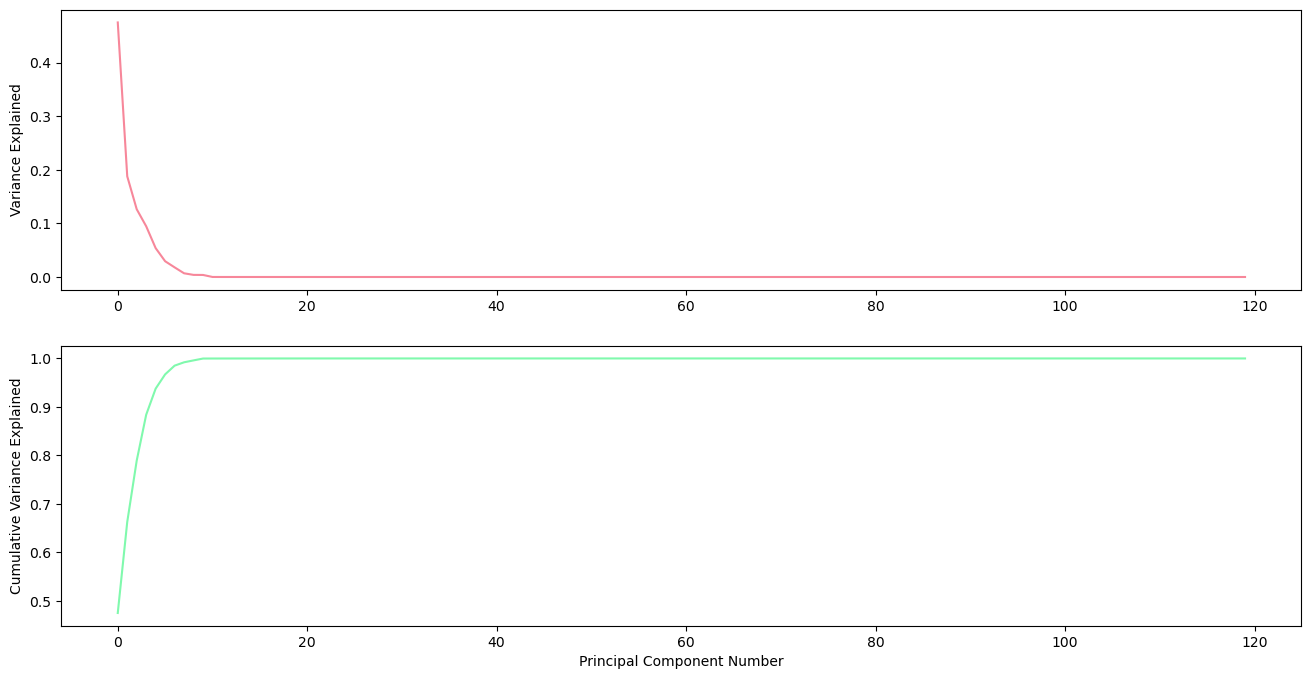

In [50]:
rrnd_x_proc_pca, rrnd_pca_model = pca_by_threshold(rrnd_x_proc[chosen_voxels])
fig, ax = pca_scree_plot(rrnd_pca_model)

In [24]:
rfef_x_proc_pca_3d_df = create_3d_dataset(rfef_x_proc_pca, roi_df)

In [51]:
rrnd_x_proc_pca_3d_df = create_3d_dataset(rrnd_x_proc_pca, con_df)

In [53]:
visualize_3d_data(rfef_x_proc_pca_3d_df[rfef_x_proc_pca_3d_df['Subjects']==1], 'rFEF', 'Session')

In [55]:
visualize_3d_data(rrnd_x_proc_pca_3d_df[rrnd_x_proc_pca_3d_df['Subjects']==5], 'rControl', 'Session')

Markedly different, though now we have to check if random spots in the brain look the same.

In [58]:
tmp = con_df[chosen_voxels].copy()

In [59]:
con_df = con_df.drop(columns=cvcols)

In [61]:
con_df = pd.concat([con_df, tmp], axis=1)

/tmp/ipykernel_9845/638106109.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipykernel_9845/638106109.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipykernel_9845/638106109.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipykernel_9845/638106109.py:1: PerformanceWarning:

,scan_time,indoor,outdoor,sess,subj,run,v8463,v6877,v10711,v11779,...,v4456,v3776,v13462,v1327,v5575,v12825,v10163,v12183,v4309,v3927
0,0.0,0.0,0.0,1,1,1,0.0,-0.000035,0.000011,0.000007,...,-0.000065,0.000000,0.000028,0.000019,0.000006,0.000011,0.000000,0.000012,0.000011,0.000000
1,2.2,0.0,0.0,1,1,1,0.0,-0.000035,0.000011,0.000014,...,-0.000065,0.000000,0.000034,0.000019,0.000006,0.000011,0.000000,0.000012,0.000023,0.000000
2,4.4,0.0,0.0,1,1,1,0.0,-0.000035,0.000000,0.000007,...,-0.000065,-0.000008,0.000028,0.000019,0.000006,0.000000,-0.000010,0.000018,0.000000,0.000000
3,6.6,0.0,0.0,1,1,1,0.0,-0.000035,0.000021,0.000028,...,-0.000065,0.000008,0.000034,0.000009,0.000018,0.000023,0.000010,0.000006,0.000056,0.000000
4,8.8,0.0,0.0,1,1,1,0.0,-0.000026,-0.000021,-0.000021,...,-0.000065,-0.000025,0.000028,0.000028,-0.000012,-0.000023,-0.000019,0.000030,-0.000068,0.000011


In [62]:
con_df.to_csv("./datasets/control_dataset_random_voxels.csv")

In [63]:
rrnd_x_proc_pca_3d_df.to_csv("./datasets/control_dataset_random_voxels_aligned_w-in_subj.csv")